# EDA — Smartports CCTV Dataset
Exploratory analysis of the dataset for the Ship/No-Ship and Docked/Undocked tasks.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('../data')
IMG_DIR  = DATA_DIR / 'images'

print('Data dir exists:', DATA_DIR.exists())
print('Images found:', len(list(IMG_DIR.glob('*'))))

Data dir exists: True
Images found: 294


## 1. Label loading

In [3]:
ship_df   = pd.read_csv(DATA_DIR / 'ship.csv',   sep=';')
docked_df = pd.read_csv(DATA_DIR / 'docked.csv', sep=';')

ship_df.columns   = ['filename', 'ship']
docked_df.columns = ['filename', 'docked']

# Full merge
full_df = ship_df.merge(docked_df, on='filename', how='left')
full_df['docked'] = full_df['docked'].fillna(-1).astype(int)  # -1 = no ship

# Basic metadata
full_df['ext']    = full_df['filename'].apply(lambda x: Path(x).suffix.lower())
full_df['prefix'] = full_df['filename'].apply(lambda x: 'ns' if x.startswith('ns') else 's')
full_df['exists'] = full_df['filename'].apply(lambda x: (IMG_DIR / x).exists())

print(f'Total images : {len(full_df)}')
print(f'Found on disk: {full_df["exists"].sum()}')
print(f'\nShip=0: {(full_df.ship==0).sum()}  |  Ship=1: {(full_df.ship==1).sum()}')
print(f'Docked=0: {(full_df.docked==0).sum()}  |  Docked=1: {(full_df.docked==1).sum()}  |  N/A(-1): {(full_df.docked==-1).sum()}')
full_df.head(8)

Total imágenes : 294
Encontradas en disco: 294

Ship=0: 110  |  Ship=1: 184
Docked=0: 92  |  Docked=1: 92  |  N/A(-1): 110


,filename,ship,docked,ext,prefix,exists
0,ns-001.jpg,0,-1,.jpg,ns,True
1,ns-002.jpg,0,-1,.jpg,ns,True
2,ns-003.jpg,0,-1,.jpg,ns,True
3,ns-004.jpg,0,-1,.jpg,ns,True
4,ns-005.jpg,0,-1,.jpg,ns,True
5,ns-006.jpg,0,-1,.jpg,ns,True
6,ns-007.jpg,0,-1,.jpg,ns,True
7,ns-008.jpg,0,-1,.jpg,ns,True


## 2. Class distribution

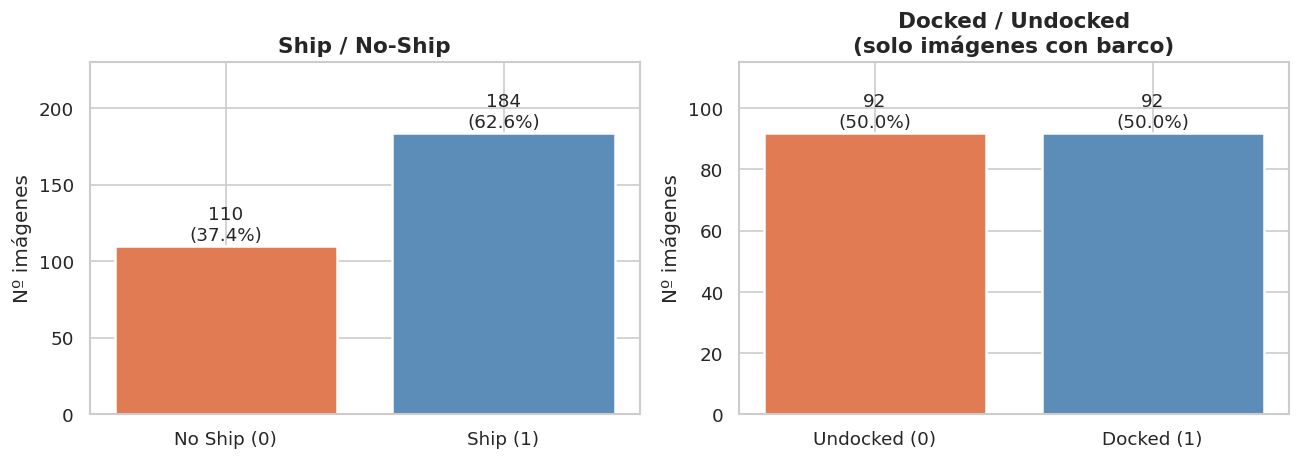

Ratio Ship/No-Ship: 1.67
pos_weight sugerido para BCEWithLogitsLoss: 0.598


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Ship / No-Ship
ship_counts = full_df['ship'].value_counts().sort_index()
bars = axes[0].bar(['No Ship (0)', 'Ship (1)'], ship_counts.values,
                   color=['#e07b54', '#5b8db8'], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, ship_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{v}\n({v/len(full_df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Ship / No-Ship', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of images')
axes[0].set_ylim(0, ship_counts.max() * 1.25)

# Docked / Undocked
docked_sub = full_df[full_df['docked'] != -1]
docked_counts = docked_sub['docked'].value_counts().sort_index()
bars2 = axes[1].bar(['Undocked (0)', 'Docked (1)'], docked_counts.values,
                    color=['#e07b54', '#5b8db8'], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars2, docked_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v}\n({v/len(docked_sub)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Docked / Undocked\n(only images with ship)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of images')
axes[1].set_ylim(0, docked_counts.max() * 1.25)

plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', bbox_inches='tight')
plt.show()

ratio = ship_counts[1] / ship_counts[0]
print(f'Ship/No-Ship ratio: {ratio:.2f}')
print(f'Suggested pos_weight for BCEWithLogitsLoss: {1/ratio:.3f}')

## 3. Formats and resolutions

In [ ]:
# Extensions
print("Extensions per class (Ship)")
print(full_df.groupby(['ext', 'ship']).size().unstack(fill_value=0)
      .rename(columns={0:'No Ship', 1:'Ship'}))

print("Extensions per prefix")
print(full_df.groupby(['prefix', 'ext']).size().unstack(fill_value=0))

# Resolutions
def get_size(filename):
    try:
        img = Image.open(IMG_DIR / filename)
        return pd.Series({'width': img.size[0], 'height': img.size[1], 'mode': img.mode})
    except:
        return pd.Series({'width': None, 'height': None, 'mode': None})

print('\nLoading resolutions...')
sizes = full_df['filename'].apply(get_size)
full_df = pd.concat([full_df, sizes], axis=1)

print('\n=== Unique resolutions (top 10) ===')
res = full_df.groupby(['width','height']).size().reset_index(name='count').sort_values('count', ascending=False)
print(res.head(10).to_string(index=False))

print(f'\nUnique color modes: {full_df["mode"].unique()}')